In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("Superstore.csv")

In [2]:
print(df.info())
df =df.drop(columns=["Row ID","Customer ID","Customer Name","Product ID","Product Name","Postal Code","Order ID"]
           )
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Ship Mode"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

C:\Users\Ayush\AppData\Local\Temp\ipykernel_26260\3284299870.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])
C:\Users\Ayush\AppData\Local\Temp\ipykernel_26260\3284299870.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"])


array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [3]:
# Creating time based 
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["DayofWeek"] = df["Order Date"].dt.dayofweek

In [4]:
# Aggregation of data
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
# daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales = daily_sales.sort_values("Order Date")

daily_sales["Year"] = daily_sales["Order Date"].dt.year
daily_sales["Month"] = daily_sales["Order Date"].dt.month
daily_sales["Day"] = daily_sales["Order Date"].dt.day
daily_sales["DayofWeek"] = daily_sales["Order Date"].dt.dayofweek
# Adding lag feature
daily_sales["Lag_1"] = daily_sales["Sales"].shift(1)
daily_sales["Lag_7"] = daily_sales["Sales"].shift(7)
daily_sales["Lag_30"] = daily_sales["Sales"].shift(30)
daily_sales = daily_sales.dropna()
df1 = pd.DataFrame(daily_sales)

# Rolling Average Calculation
df1["Rolling_7"] = df1["Sales"].rolling(window=7).mean()
df1["Rolling_30"] = df1["Sales"].rolling(window=30).mean()

df1.head(20)

,Order Date,Sales,Year,Month,Day,DayofWeek,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
30,2014-02-12,129.568,2014,2,12,2,2043.400,211.646,16.448,NaN,NaN
31,2014-02-14,576.726,2014,2,14,4,129.568,97.112,288.060,NaN,NaN
32,2014-02-15,21.360,2014,2,15,5,576.726,134.384,19.536,NaN,NaN
33,2014-02-16,9.040,2014,2,16,6,21.360,330.512,4407.100,NaN,NaN
34,2014-02-17,54.208,2014,2,17,0,9.040,180.320,87.158,NaN,NaN
35,2014-02-18,37.784,2014,2,18,1,54.208,14.560,40.544,NaN,NaN
36,2014-02-20,95.590,2014,2,20,3,37.784,2043.400,54.830,132.039429,NaN
37,2014-02-21,8.850,2014,2,21,4,95.590,129.568,9.940,114.794000,NaN
38,2014-02-22,19.440,2014,2,22,5,8.850,576.726,3553.795,35.181714,NaN
39,2014-02-23,11.364,2014,2,23,6,19.440,21.360,61.960,33.753714,NaN


In [5]:
df1.isnull().sum()
# df = pd.get_dummies(df, columns=["Ship Mode","Region","Category","Segment"], dtype=int)

Order Date     0
Sales          0
Year           0
Month          0
Day            0
DayofWeek      0
Lag_1          0
Lag_7          0
Lag_30         0
Rolling_7      6
Rolling_30    29
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9994 non-null   datetime64[ns]
 1   Ship Date     9994 non-null   datetime64[ns]
 2   Ship Mode     9994 non-null   object        
 3   Segment       9994 non-null   object        
 4   Country       9994 non-null   object        
 5   City          9994 non-null   object        
 6   State         9994 non-null   object        
 7   Region        9994 non-null   object        
 8   Category      9994 non-null   object        
 9   Sub-Category  9994 non-null   object        
 10  Sales         9994 non-null   float64       
 11  Quantity      9994 non-null   int64         
 12  Discount      9994 non-null   float64       
 13  Profit        9994 non-null   float64       
 14  Year          9994 non-null   int32         
 15  Month         9994 non-null   int32   

In [7]:
df1

,Order Date,Sales,Year,Month,Day,DayofWeek,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
30,2014-02-12,129.5680,2014,2,12,2,2043.4000,211.646,16.448,NaN,NaN
31,2014-02-14,576.7260,2014,2,14,4,129.5680,97.112,288.060,NaN,NaN
32,2014-02-15,21.3600,2014,2,15,5,576.7260,134.384,19.536,NaN,NaN
33,2014-02-16,9.0400,2014,2,16,6,21.3600,330.512,4407.100,NaN,NaN
34,2014-02-17,54.2080,2014,2,17,0,9.0400,180.320,87.158,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1232,2017-12-26,814.5940,2017,12,26,1,2698.9270,1895.926,3666.157,3090.578286,3302.718267
1233,2017-12-27,177.6360,2017,12,27,2,814.5940,377.736,5048.172,3061.992571,3140.367067
1234,2017-12-28,1657.3508,2017,12,28,3,177.6360,2140.940,1618.254,2992.908400,3141.670293
1235,2017-12-29,2915.5340,2017,12,29,4,1657.3508,7442.021,6912.944,2346.267400,3008.423293


# EDA

In [8]:
df1.columns

Index(['Order Date', 'Sales', 'Year', 'Month', 'Day', 'DayofWeek', 'Lag_1',
       'Lag_7', 'Lag_30', 'Rolling_7', 'Rolling_30'],
      dtype='object')

<Axes: xlabel='Year', ylabel='Sales'>

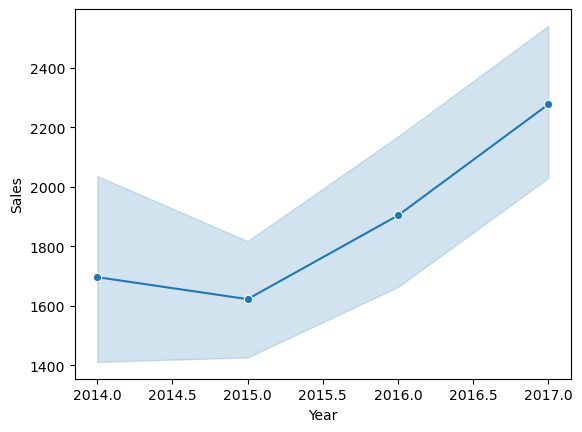

In [23]:
sns.lineplot(
    data = df1,
    x = "Year",
    y= "Sales",
    marker="o",
)
# sale is drecreasing from 2014-2015 lowest at 2015
# 2015-2017 sale is increasing , highest in 2017

<Axes: xlabel='Month', ylabel='Sales'>

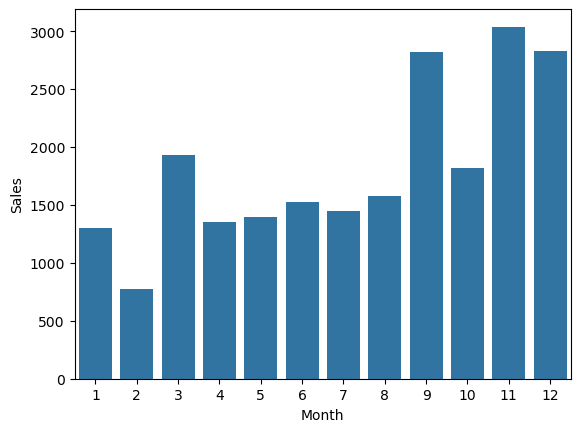

In [9]:
sns.barplot(
    data = df1,
    x = "Month",
    y = "Sales",
    errorbar = None
)

<Axes: xlabel='DayofWeek', ylabel='Sales'>

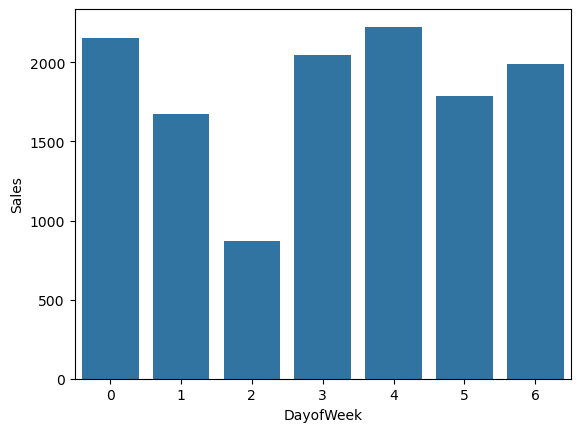

In [10]:
sns.barplot(
    data = df1,
    x = "DayofWeek",
    y = "Sales",
    errorbar = None
)

<Axes: xlabel='Day', ylabel='Sales'>

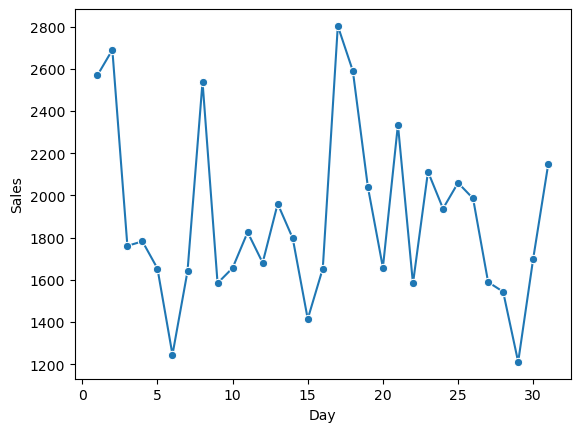

In [11]:
sns.lineplot(
    data = df1,
    x = "Day",
    y = "Sales",
    errorbar =None,
    marker="o"
)

<Axes: xlabel='Order Date', ylabel='Sales'>

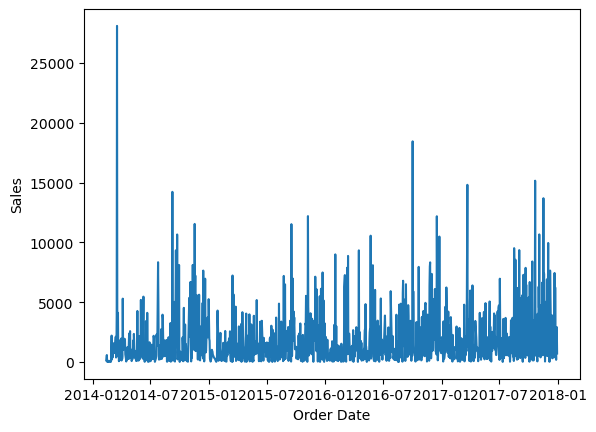

In [12]:

sns.lineplot(x='Order Date', y='Sales', data=df1)

<Axes: xlabel='DayofWeek', ylabel='Sales'>

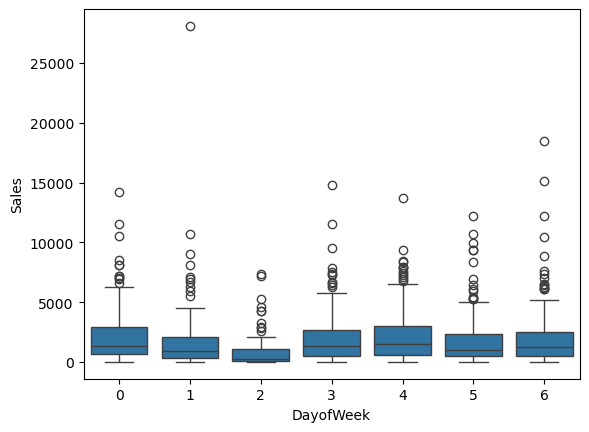

In [13]:
sns.boxplot(x='DayofWeek', y='Sales', data=df1)

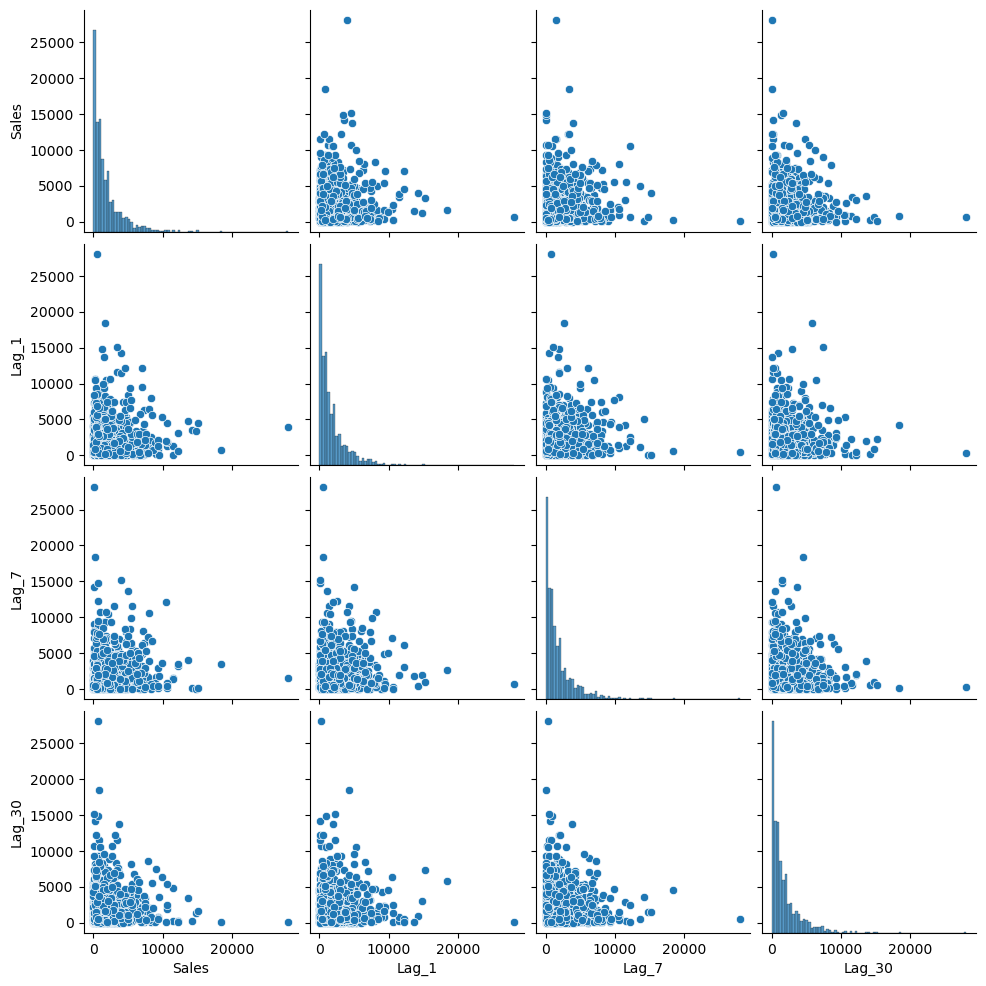

In [14]:
sns.pairplot(df1[["Sales", "Lag_1", "Lag_7","Lag_30"]])
plt.show()

               Sales      Year     Month       Day  DayofWeek     Lag_1  \
Sales       1.000000  0.099057  0.229093 -0.025973   0.017485  0.100045   
Year        0.099057  1.000000 -0.070188 -0.008796   0.018442  0.100076   
Month       0.229093 -0.070188  1.000000 -0.007401  -0.022103  0.226767   
Day        -0.025973 -0.008796 -0.007401  1.000000  -0.007870 -0.023836   
DayofWeek   0.017485  0.018442 -0.022103 -0.007870   1.000000 -0.020304   
Lag_1       0.100045  0.100076  0.226767 -0.023836  -0.020304  1.000000   
Lag_7       0.115187  0.107602  0.208399  0.039636  -0.019768  0.101502   
Lag_30      0.013683  0.128329  0.125569 -0.003997  -0.041777  0.033023   
Rolling_7   0.444688  0.216855  0.487715  0.021922  -0.009401  0.445221   
Rolling_30  0.296288  0.332939  0.564854  0.016138  -0.013641  0.303794   

               Lag_7    Lag_30  Rolling_7  Rolling_30  
Sales       0.115187  0.013683   0.444688    0.296288  
Year        0.107602  0.128329   0.216855    0.332939  
Month 

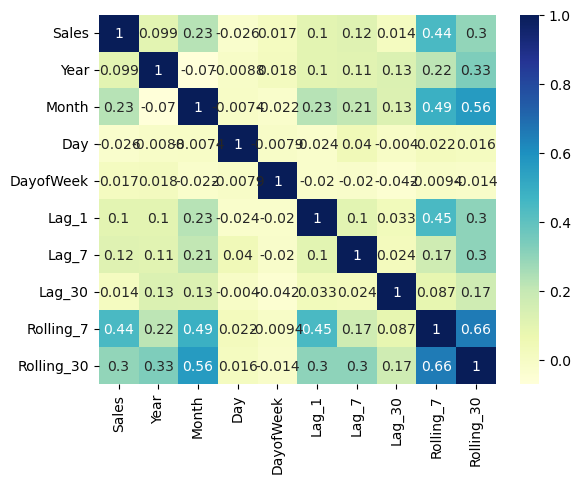

In [15]:
co_mtx = df1.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

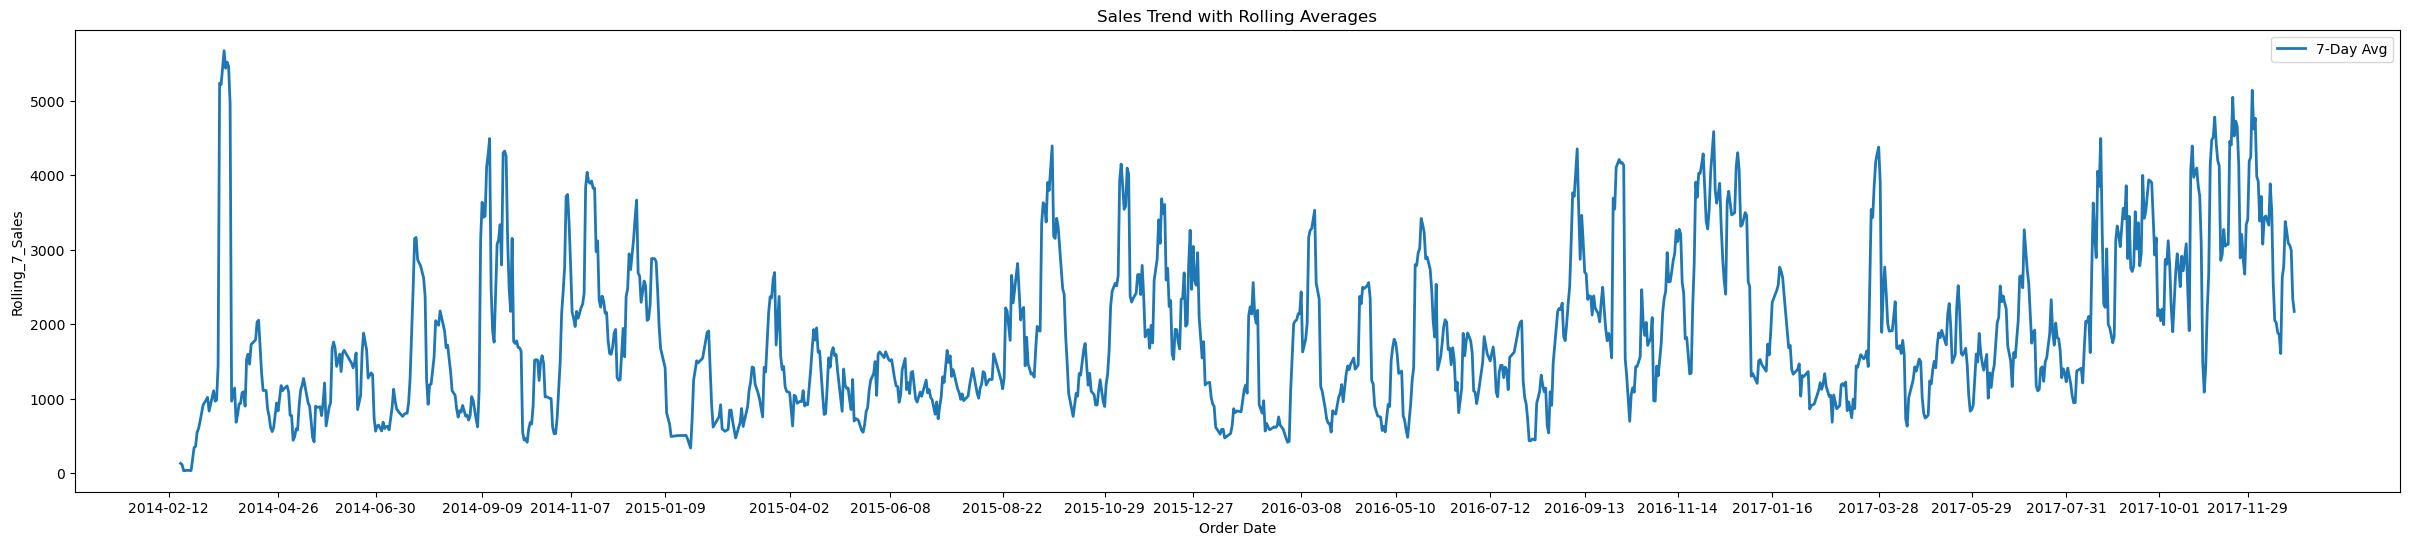

In [16]:

plt.figure(figsize=(30,6))
plt.plot(df1['Order Date'], df1['Rolling_7'], label='7-Day Avg', linewidth=2)

plt.title('Sales Trend with Rolling Averages')
plt.xlabel('Order Date')
plt.ylabel('Rolling_7_Sales')
plt.legend()
plt.xticks(df1['Order Date'][::56])  # show every 5th date
plt.show()
# feb, sept, oct ->2014, 
# sept, nov , dec ->2015,


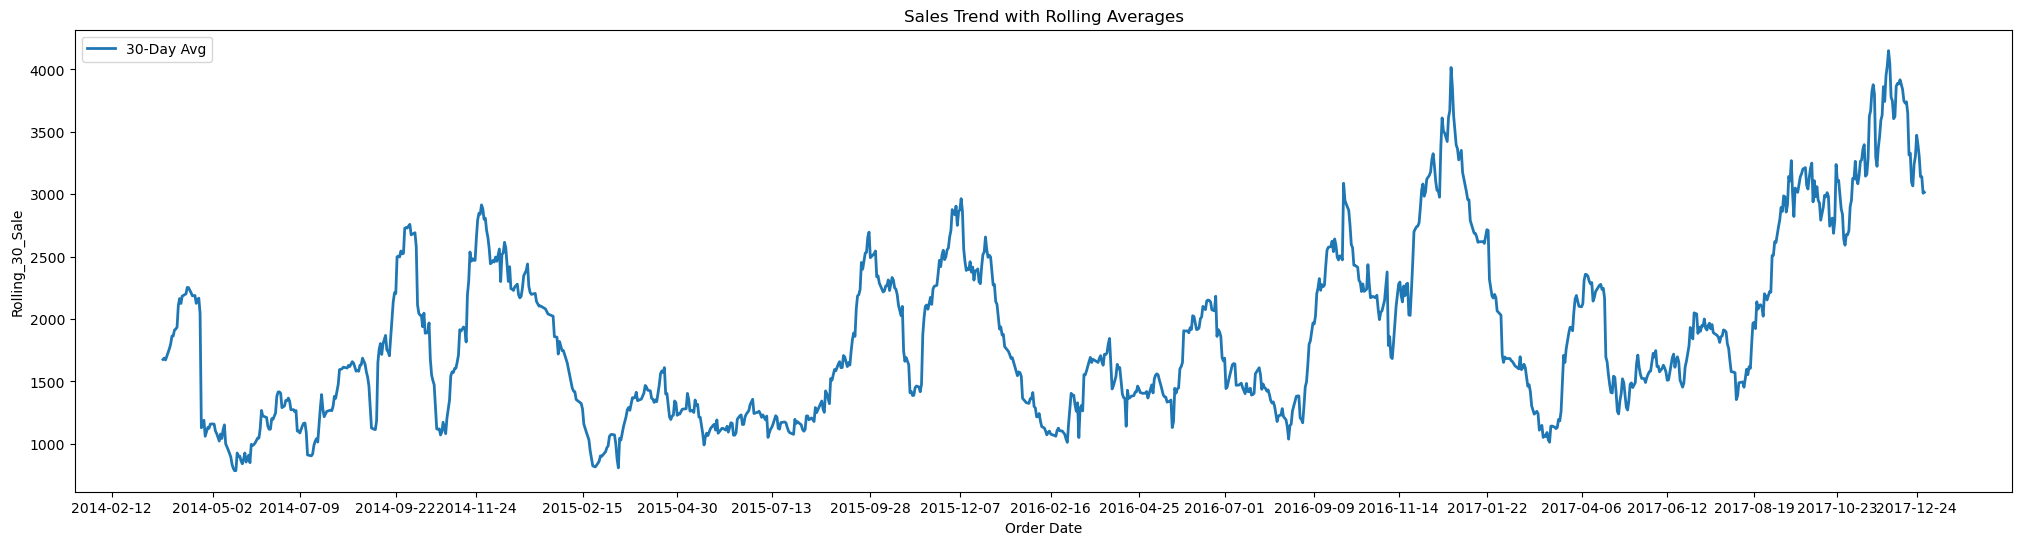

In [17]:
plt.figure(figsize=(25,6))
plt.plot(df1['Order Date'], df1['Rolling_30'], label='30-Day Avg', linewidth=2)

plt.title('Sales Trend with Rolling Averages')
plt.xlabel('Order Date')
plt.ylabel('Rolling_30_Sale')
plt.legend()
plt.xticks(df1['Order Date'][::60])
plt.show()

In [18]:
# After mid 2016 to 2017 year sales is high it means sales are increasing year to year
# highest sales November > September & December , lowest sale = February < April = January
# For DayofWeek
# Day 3 and 6  have highest outlier may be some occassion or event takes place
# Day 2 has lowest sales 
#Day 1 has largest outliers
# Day 4 has highest median sales

# Day wise Analysis
# Highest sale on day 17>2>1>18>7
# lowest sale on day 6<28<15
# day 8 has gradual decrease in sale
# 04-2014 , 09-0214, 11-2014, 09-2015, 11-2015,12-2015, 09,10-2016 ,12-2016,01-2017 ,11-2017 has highest sales month
# 05 to 08 - 2014 , 02 to 08 - 2015 have less sale , 02-2016 to 09-2016 , 05 to 08 2017
# 12-2014 to 01-2015 , 01-2016, 02 to 03- 2017 sales gradually decrease


# Best Business Insights

In [19]:
# Inventory: Increase stock during Sep–Dec and high-demand days (Tue, Thu, Fri, Sun).
# Marketing: Run promotions during Jan–Apr and low-performing days (Wednesday).
# Staffing: Allocate more staff during peak periods to handle demand efficiently.
# Planning: Use seasonal and weekly patterns to improve forecasting and operations.